# DGCNN for ModelNet40
Adapted to the ModelNet40 dataset. This notebook uses all 40 classes.

we write the dimensions as such:
- D is the amount of features (3 features: x, y, z)
- N is the amount of points per mesh
- B is the amount of batches

Among the N dimension, theres invariance by permutation because point order doesnt matter.

In [1]:
from functools import lru_cache
from pathlib import Path
import time
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from IPython.display import clear_output

In [ ]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar')
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'ModelNet40'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'modelNET_pointnetV1'
SEEDS = [12, 13, 14, 15, 16] # reproduce results and check initialization sentivity
DEVICE = "mps"

MODELNET_CLASS_NAMES = (
    'airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair', 'cone',
    'cup', 'curtain', 'desk', 'door', 'dresser', 'flower_pot', 'glass_box', 'guitar', 'keyboard', 'lamp',
    'laptop', 'mantel', 'monitor', 'night_stand', 'person', 'piano', 'plant', 'radio', 'range_hood', 'sink',
    'sofa', 'stairs', 'stool', 'table', 'tent', 'toilet', 'tv_stand', 'vase', 'wardrobe', 'xbox')

CONFIG = {
    'feature_names': ('x', 'y', 'z'),
    'surface_points_per_model': 2048,
    'points_per_model': 1024, # the amount of points from the paper that saturates performances
    'batch_size': 64,
    'dropout_rate': 0.3,
    'k': 20,
    'emb_dims': 1024,
    'smoothing': 0.1,  # label smoothing for generalization
    'train_fraction': 0.1, # to iterate faster
    'valid_fraction': 0.2, # for training stopping
    "num_epochs": 50,
    "base_lr": 1e-3,
    "min_lr": 1e-5,
    "adam_momentum": 0.9,
    "lr_decay_samples": 200000,  # reduce LR every N samples (better than epochs)
    "lr_decay_gamma": 0.7,
}

# data preparation

In [3]:
@lru_cache(maxsize=None)
def load_modelnet_file(file_path):
    "Load an OFF mesh and return normalized surface-sampled points."
    with Path(file_path).open('r') as handle:
        header = handle.readline().split()
        counts = header[1:] if len(header) > 1 and header[0] == 'OFF' else ([header[0][3:], *header[1:]] if header[0] != 'OFF' else handle.readline().split())
        vertex_count, face_count = int(counts[0]), int(counts[1])
        vertices = torch.tensor([[float(value) for value in handle.readline().split()[:3]] for _ in range(vertex_count)], dtype=torch.float32)
        triangles = []
        for _ in range(face_count):
            face = [int(value) for value in handle.readline().split()]
            triangles.extend([face[1], face[i], face[i + 1]] for i in range(2, face[0]))

    triangles = vertices[torch.tensor(triangles, dtype=torch.long)]
    vectors = triangles[:, 1:] - triangles[:, :1]
    areas = torch.cross(vectors[:, 0], vectors[:, 1], dim=1).norm(dim=1)
    valid = torch.isfinite(areas) & (areas > 0)
    triangles, areas = triangles[valid], areas[valid]
    chosen = triangles[torch.multinomial(areas, CONFIG['surface_points_per_model'], replacement=True)]
    u, v = torch.rand(CONFIG['surface_points_per_model'], 1), torch.rand(CONFIG['surface_points_per_model'], 1)
    over = (u + v).squeeze(1) > 1
    u[over], v[over] = 1 - u[over], 1 - v[over]
    points = chosen[:, 0] + u * (chosen[:, 1] - chosen[:, 0]) + v * (chosen[:, 2] - chosen[:, 0])
    points = points - points.mean(dim=0)
    points = points / torch.norm(points, dim=1).max()
    return points[:CONFIG['points_per_model']]

In [4]:
def build_sample_index(split_name):
    "Creates one sample per OFF file."
    samples = []
    for class_name in MODELNET_CLASS_NAMES:
        for file_path in sorted(DATA_ROOT.rglob(f'{class_name}/{split_name}/*.off')):
            samples.append((str(file_path), MODELNET_CLASS_NAMES.index(class_name)))
    return samples

In [5]:
@lru_cache(maxsize=None)
def validation_split(seed):
    "Split a smaller ModelNet train subset into train and validation samples."
    all_train_samples = build_sample_index('train')
    generator = torch.Generator().manual_seed(seed)
    train_samples, valid_samples = [], []
    for class_idx in range(len(MODELNET_CLASS_NAMES)):
        class_samples = [sample for sample in all_train_samples if sample[1] == class_idx]
        order = torch.randperm(len(class_samples), generator=generator).tolist()
        selected = [class_samples[idx] for idx in order[:int(len(class_samples) * CONFIG['train_fraction'])]]
        valid_count = int(len(selected) * CONFIG['valid_fraction'])
        valid_samples.extend(selected[:valid_count])
        train_samples.extend(selected[valid_count:])
    return train_samples, valid_samples

In [6]:
sample_file = next(DATA_ROOT.rglob('*.off'))
points = load_modelnet_file(str(sample_file))
print(len(points))
print(points.shape) # (points_per_model, len(feature_names))

1024
torch.Size([1024, 3])


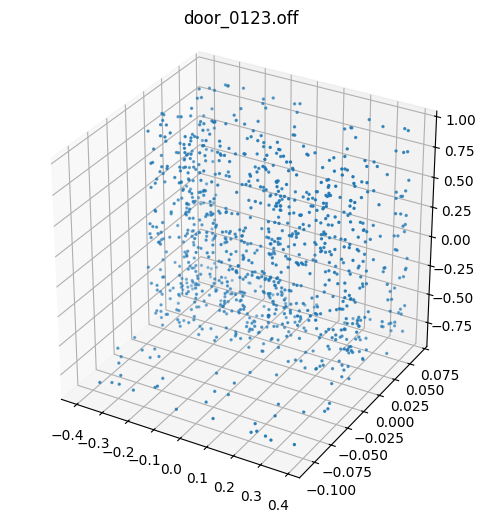

In [7]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2)
ax.set_title(sample_file.name)
ax.set_box_aspect((1, 1, 1))
plt.show()

In [8]:
def augmentation(point_cloud):
    "Training augmentation."
    angle = torch.empty(()).uniform_(0, 2 * torch.pi).item()
    cosval, sinval = torch.cos(torch.tensor(angle)).item(), torch.sin(torch.tensor(angle)).item()
    rotation = point_cloud.new_tensor([[cosval, 0.0, sinval], [0.0, 1.0, 0.0], [-sinval, 0.0, cosval]])
    jitter = (torch.randn_like(point_cloud) * 0.01).clamp(-0.05, 0.05)
    return point_cloud @ rotation + jitter

In [ ]:
class ModelNetDataset(Dataset):
    "Dataset containing ModelNet point clouds."
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label_idx = self.samples[idx]
        point_cloud = load_modelnet_file(file_path)
        if self.augment:
            point_cloud = augmentation(point_cloud)
        label = torch.tensor(label_idx, dtype=torch.long)
        return point_cloud, label

# architecture

In [10]:
def xavier_init(module):
    "Helper to initialize weights with Xavier uniform, ignoring biaises and scalars."
    for p in module.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

In [11]:
def knn(x, k):
    "Find the k nearest neighbors for each point."
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x ** 2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    return pairwise_distance.topk(k=k, dim=-1)[1]

In [12]:
def get_graph_feature(x, k=20):
    "Build DGCNN edge features: neighbor - point, point."
    batch_size, feature_count, point_count = x.shape
    idx = knn(x, k=k) + torch.arange(batch_size, device=x.device).view(-1, 1, 1) * point_count
    x = x.transpose(2, 1).contiguous()
    feature = x.view(batch_size * point_count, feature_count)[idx.view(-1)]
    feature = feature.view(batch_size, point_count, k, feature_count)
    x = x.view(batch_size, point_count, 1, feature_count).repeat(1, 1, k, 1)
    return torch.cat((feature - x, x), dim=3).permute(0, 3, 1, 2).contiguous()

In [13]:
class DGCNN(nn.Module):
    "Dynamic Graph CNN architecture from the reference implementation."
    def __init__(self, feature_count):
        super().__init__()
        self.k = CONFIG['k']
        self.conv1 = nn.Sequential(nn.Conv2d(feature_count * 2, 64, 1, bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(0.2))
        self.conv2 = nn.Sequential(nn.Conv2d(64 * 2, 64, 1, bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(0.2))
        self.conv3 = nn.Sequential(nn.Conv2d(64 * 2, 128, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2))
        self.conv4 = nn.Sequential(nn.Conv2d(128 * 2, 256, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2))
        self.conv5 = nn.Sequential(nn.Conv1d(512, CONFIG['emb_dims'], 1, bias=False), nn.BatchNorm1d(CONFIG['emb_dims']), nn.LeakyReLU(0.2))
        self.linear1 = nn.Linear(CONFIG['emb_dims'] * 2, 512, bias=False)
        self.bn6 = nn.BatchNorm1d(512)
        self.linear2 = nn.Linear(512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.linear3 = nn.Linear(256, len(MODELNET_CLASS_NAMES))
        self.dropout = nn.Dropout(CONFIG['dropout_rate'])
        xavier_init(self)

    def forward(self, x):
        batch_size = x.size(0)
        x = x.transpose(2, 1).contiguous()
        x = self.conv1(get_graph_feature(x, k=self.k)); x1 = x.max(dim=-1)[0]
        x = self.conv2(get_graph_feature(x1, k=self.k)); x2 = x.max(dim=-1)[0]
        x = self.conv3(get_graph_feature(x2, k=self.k)); x3 = x.max(dim=-1)[0]
        x = self.conv4(get_graph_feature(x3, k=self.k)); x4 = x.max(dim=-1)[0]
        x = self.conv5(torch.cat((x1, x2, x3, x4), dim=1))
        x = torch.cat((F.adaptive_max_pool1d(x, 1).view(batch_size, -1), F.adaptive_avg_pool1d(x, 1).view(batch_size, -1)), dim=1)
        x = self.dropout(F.leaky_relu(self.bn6(self.linear1(x)), negative_slope=0.2))
        x = self.dropout(F.leaky_relu(self.bn7(self.linear2(x)), negative_slope=0.2))
        return self.linear3(x)

In [14]:
train_samples, valid_samples = validation_split(SEEDS[0])
test_samples = build_sample_index('test')
print(f'Train samples: {len(train_samples)}')
print(f'Validation samples: {len(valid_samples)}')
print(f'Test samples: {len(test_samples)}')

Train samples: 789
Validation samples: 177
Test samples: 2468


In [ ]:
# sanity check
model = DGCNN(len(CONFIG["feature_names"]))

train_dataset = ModelNetDataset(train_samples, augment=True)
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
sample_batch, sample_labels = next(iter(train_loader))
output = model(sample_batch)

print(f'Input shape: {sample_batch.shape}')
print(f'Label shape: {sample_labels.shape}')
print(f'Output shape: {output.shape}')

# training

In [ ]:
def create_dataloaders(batch_size, seed):
    "Create train and validation dataloaders."
    train_samples, valid_samples = validation_split(seed)
    train_dataset = ModelNetDataset(train_samples, augment=True)
    valid_dataset = ModelNetDataset(valid_samples)
    generator = torch.Generator().manual_seed(seed)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, generator=generator)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_dataloader, valid_dataloader

In [ ]:
def rate(sample_count, base):
    "Every 200k samples, the LR is multiplied by 0.7"
    decay_count = sample_count // CONFIG["lr_decay_samples"]
    return max(base * CONFIG["lr_decay_gamma"] ** decay_count, CONFIG["min_lr"])

In [ ]:
def smoothing(pred, targets, smoothing=0):
    "The true class becomes 1-smoothing, and the rest of the probability is distributed amongst the other classes"
    targets = targets.contiguous().view(-1)
    class_amount = pred.size(1)
    one_hot = torch.zeros_like(pred).scatter(1, targets.view(-1, 1), 1)
    one_hot = one_hot * (1 - smoothing) + (1 - one_hot) * smoothing / (class_amount - 1)
    log_prob = F.log_softmax(pred, dim=1)
    return -(one_hot * log_prob).sum(dim=1).mean()

In [ ]:
class Loss:
    "Cross-entropy loss with smoothing."
    def __init__(self, model):
        self.model = model

    def __call__(self, out, targets, batch_size):
        loss_node = smoothing(out, targets, CONFIG['smoothing'])
        loss = loss_node.detach() * batch_size
        return loss, loss_node

In [ ]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, mode="train", seen_samples=0):
    "Runs one epoch, either for training, either validation."
    start, device = time.time(), torch.device(DEVICE)
    total_tokens, total_loss, tokens = 0, 0, 0
    loss_list, grad_norms = [], []
    for i, (src, targets) in enumerate(data_iter):
        src, targets = src.to(device), targets.to(device)
        ntokens = targets.size(0)
        loss, loss_node = loss_compute(model.forward(src), targets, ntokens)

        if mode == "train":
            for param_group in optimizer.param_groups: param_group["lr"] = rate(seen_samples, CONFIG["base_lr"])
            loss_node.backward()
            if optimizer is not None:
                norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float("inf")).item()
                grad_norms.append(norm)
                optimizer.step(); optimizer.zero_grad(set_to_none=True)
            seen_samples += ntokens
        total_loss += loss; total_tokens += ntokens; tokens += ntokens
        loss_list.append((loss / ntokens).item())
        if mode == "train":
            lr, elapsed = optimizer.param_groups[0]["lr"], time.time() - start
            print(f"Batch: {i:6d} | Loss: {loss / ntokens:6.2f} | Samples/sec: {tokens / elapsed:7.1f} | Learn. Rate: {lr:6.1e}")
            start, tokens = time.time(), 0

    return loss_list, grad_norms, seen_samples

In [ ]:
def plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means):
    "Plot the losses and the gradient norm over the training process."
    x_train = [e + i / s for e, s in enumerate(train_epoch_sizes) for i in range(s)]
    x_valid = [e + i / s for e, s in enumerate(valid_epoch_sizes) for i in range(s)]
    epoch_mean_valid_losses = [m for s, m in zip(valid_epoch_sizes, epoch_means) for _ in range(s)]
    tick_step = max(1, (num_epochs + 19) // 20)
    epoch_ticks = list(range(0, num_epochs + 1, tick_step))
    if epoch_ticks[-1] != num_epochs: epoch_ticks.append(num_epochs)
    plt.figure(figsize=(10, 10))
    ax1 = plt.subplot(2, 1, 1)
    w = max(1, int((len(train_losses) / num_epochs) * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=w, center=True).mean()
    plt.plot(x_train, train_losses, label="Training Loss"); plt.plot(x_train, train_loss_rolling, label="Training Loss (Avg)", color="darkblue", linewidth=1); plt.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7); plt.plot(x_valid, epoch_mean_valid_losses, label="Val Loss (Avg)", color="red", linewidth=1, linestyle="--")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Training and Validation Loss Over Epochs")
    ax1.set_xlim(0, num_epochs); ax1.set_xticks(epoch_ticks)
    loss_values = pd.Series(train_losses + valid_losses + epoch_means).dropna()
    q1, q3 = loss_values.quantile(0.25), loss_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < loss_values.max(): ax1.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    y_min, y_max = ax1.get_ylim()
    best_mean_val = float("inf")
    for i, mean_val in enumerate(epoch_means):
        if mean_val <= best_mean_val and y_min <= mean_val <= y_max: ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}", color="red", ha="center", va="bottom", fontweight="medium", clip_on=True)
        best_mean_val = min(best_mean_val, mean_val)
    ax = plt.subplot(2, 1, 2)
    plt.plot(x_train, all_grad_norms, label="Gradient Norm", color="orange"); plt.xlabel("Epochs"); plt.ylabel("Norm"); plt.legend(); plt.title("Gradient Norm over Epochs")
    ax.set_xlim(0, num_epochs); ax.set_xticks(epoch_ticks)
    grad_values = pd.Series(all_grad_norms).dropna()
    q1, q3 = grad_values.quantile(0.25), grad_values.quantile(0.75)
    central_grad_values = grad_values[grad_values <= q3 + 1.5 * (q3 - q1)]
    grad_threshold = central_grad_values.mean() + 25 * central_grad_values.var()
    visible_grad_values = grad_values[grad_values <= grad_threshold]
    bottom, top = visible_grad_values.min(), visible_grad_values.max()
    margin = max((top - bottom) * 0.05, 1e-6)
    ax.set_ylim(max(0, bottom - margin), top + margin)
    ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="dimgray")
    plt.subplots_adjust(hspace=0.35); plt.show()

In [ ]:
def train_model(seed, num_epochs):
    "Training process of the model, over all the epochs."
    torch.manual_seed(seed)
    load_modelnet_file.cache_clear()
    print(f"Training process starting for seed {seed}...", flush=True)
    model = DGCNN(len(CONFIG["feature_names"])).to(torch.device(DEVICE))
    model_param_count = sum(p.numel() for p in model.parameters())
    train_dataloader, valid_dataloader = create_dataloaders(CONFIG["batch_size"], seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=rate(0, CONFIG["base_lr"]), betas=(CONFIG["adam_momentum"], 0.999))
    train_losses, valid_losses, all_grad_norms = [], [], []
    train_epoch_sizes, valid_epoch_sizes, epoch_means = [], [], []
    seen_samples = 0
    loss_compute, checkpoint_dir = Loss(model), CHECKPOINT_ROOT / f"seed_{seed}"
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(num_epochs):
        model.train(); print(f"Epoch n°{epoch} Training ====", flush=True)
        loss_list, grad_norms, seen_samples = run_epoch(train_dataloader, model, loss_compute, optimizer, mode="train", seen_samples=seen_samples)
        train_losses.extend(loss_list); train_epoch_sizes.append(len(loss_list)); all_grad_norms.extend(grad_norms)
        torch.save(model.state_dict(), checkpoint_dir / f"checkpoint_{epoch:02d}.pt")
        clear_output(wait=True)
        print(f"Training process starting for seed {seed}...", flush=True)
        if len(valid_dataloader) > 0:
            print(f"Epoch n°{epoch} Validation ====", flush=True); model.eval()
            with torch.no_grad():
                loss_list, _, _ = run_epoch(valid_dataloader, model, loss_compute, None, mode="eval")
            valid_losses.extend(loss_list); valid_epoch_sizes.append(len(loss_list))
            mean_val = sum(loss_list) / len(loss_list); epoch_means.append(mean_val)
            print(f"Epoch n°{epoch} complete | Validation loss: {mean_val:.4f}", flush=True)
        plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means)

In [ ]:
if __name__ == "__main__":
    for seed in SEEDS:
        train_model(seed, CONFIG['num_epochs'])

Training process starting for seed 12...
Epoch n°0 Training ====
Batch:      0 | Loss:   3.74 | Samples/sec:    10.9 | Learn. Rate: 1.0e-03
Batch:      1 | Loss:   3.63 | Samples/sec:    19.4 | Learn. Rate: 1.0e-03
Batch:      2 | Loss:   3.61 | Samples/sec:    20.1 | Learn. Rate: 1.0e-03
Batch:      3 | Loss:   3.56 | Samples/sec:    25.5 | Learn. Rate: 1.0e-03


KeyboardInterrupt: 

# inference/evalutation

In [ ]:
def compute_f1(predictions, labels):
    "Compute the macro F1 score."
    scores = []
    for class_idx in range(len(MODELNET_CLASS_NAMES)):
        true_positive = ((predictions == class_idx) & (labels == class_idx)).sum().item()
        false_positive = ((predictions == class_idx) & (labels != class_idx)).sum().item()
        false_negative = ((predictions != class_idx) & (labels == class_idx)).sum().item()
        denominator = 2 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0 else 2 * true_positive / denominator)
    return torch.tensor(scores, dtype=torch.float32)

In [ ]:
def evaluate_validation(epoch, seed):
    "Score a checkpoint on validation set for accuracy and F1."
    checkpoint_path = CHECKPOINT_ROOT / f"seed_{seed}" / f"checkpoint_{epoch:02d}.pt"
    device = torch.device(DEVICE)
    model = DGCNN(len(CONFIG['feature_names'])).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device)); model.eval()
    eval_loader = DataLoader(ModelNetDataset(validation_split(seed)[1]), batch_size=CONFIG['batch_size'], shuffle=False)

    predictions, true_labels = [], []
    with torch.no_grad():
        for batch, labels in eval_loader:
            predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            true_labels.append(labels.cpu())

    predictions, labels = torch.cat(predictions), torch.cat(true_labels)
    per_class_f1 = compute_f1(predictions, labels)
    accuracy = (predictions == labels).float().mean().item()
    per_class_scores = {name: float(score) for name, score in zip(MODELNET_CLASS_NAMES, per_class_f1)}
    return per_class_f1.mean().item(), per_class_scores, accuracy

In [ ]:
def plot_validation_metrics(seed):
    "Plot validation accuracy and F1 for every checkpoint."
    torch.manual_seed(seed); load_modelnet_file.cache_clear()
    checkpoint_id = lambda path: int(path.stem.split("_")[-1])
    checkpoint_paths = sorted((CHECKPOINT_ROOT / f"seed_{seed}").glob("checkpoint_*.pt"), key=checkpoint_id)
    if len(validation_split(seed)[1]) == 0: return None

    checkpoint_numbers = [checkpoint_id(path) for path in checkpoint_paths]
    metrics = [evaluate_validation(checkpoint, seed) for checkpoint in checkpoint_numbers]
    macro_f1_scores, accuracy_scores = ([metric[i] for metric in metrics] for i in (0, 2))

    fig, ax = plt.subplots(figsize=(10, 5))
    lines = [ax.plot(checkpoint_numbers, scores, marker="o", label=label)[0] for scores, label in ((macro_f1_scores, "Macro F1"), (accuracy_scores, "Accuracy"))]
    for scores, line, offset in zip((macro_f1_scores, accuracy_scores), lines, (0.02, 0.05)):
        best = -1
        for checkpoint, score in zip(checkpoint_numbers, scores):
            if score > best:
                ax.text(checkpoint, score + offset, f"{score:.3f}", ha="center", color=line.get_color())
                best = score

    tick_step = 1 if len(checkpoint_paths) <= 20 else max(2, (len(checkpoint_paths) + 14) // 15)
    tick_indices = list(range(0, len(checkpoint_paths), tick_step))
    ax.set_xticks([checkpoint_numbers[i] for i in tick_indices],
                  [checkpoint_paths[i].stem for i in tick_indices], rotation=45, ha="right")
    ax.set_xlim(checkpoint_numbers[0] - 0.5, checkpoint_numbers[-1] + 0.5)
    ax.set_ylim(min(macro_f1_scores + accuracy_scores) - 0.02, 1)
    ax.set(xlabel="Checkpoint", ylabel="Score", title="Validation checkpoint performance")
    ax.legend(); fig.tight_layout(); plt.show()
    best_checkpoint = checkpoint_numbers[accuracy_scores.index(max(accuracy_scores))]
    print(f'Seed {seed} best accuracy checkpoint: {best_checkpoint}')
    return best_checkpoint

In [ ]:
best_by_seed = {seed: plot_validation_metrics(seed) for seed in SEEDS}

In [ ]:
def evaluate_test(epoch, seed):
    "Evaluate a checkpoint epoch on test."
    torch.manual_seed(seed); load_modelnet_file.cache_clear()
    checkpoint_path, device = CHECKPOINT_ROOT / f"seed_{seed}" / f"checkpoint_{epoch:02d}.pt", torch.device(DEVICE)
    model = DGCNN(len(CONFIG['feature_names'])).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device)); model.eval()

    eval_loader = DataLoader(
        ModelNetDataset(build_sample_index('test')), batch_size=CONFIG['batch_size'], shuffle=False)

    predictions, true_labels = [], []
    with torch.no_grad():
        for batch, labels in eval_loader:
            predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            true_labels.append(labels.cpu())

    predictions, labels = torch.cat(predictions), torch.cat(true_labels)
    per_class_f1 = compute_f1(predictions, labels)
    per_class_scores = {name: float(score) for name, score in zip(MODELNET_CLASS_NAMES, per_class_f1)}
    test_macro_f1, test_accuracy = per_class_f1.mean().item(), (predictions == labels).float().mean().item()
    print(f'Seed {seed} | Test macro F1: {test_macro_f1:.4f}\nSeed {seed} | Test accuracy: {test_accuracy:.4f}')
    #print(per_class_scores)
    return test_accuracy

In [ ]:
best_test_scores = {seed: evaluate_test(best_by_seed[seed], seed) for seed in SEEDS}
#last_test_scores = {seed: evaluate_test(CONFIG['num_epochs'] - 1, seed) for seed in SEEDS}
print('Best checkpoint test scores:', best_test_scores)
#print('Last checkpoint test scores:', last_test_scores)